In [42]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import re
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import time

In [2]:
# отключаем экспоненциальное отображение чисел в pandas и numpy и делаем удобное форматирование
def smart_float(x):
    if pd.isnull(x):
        return ""
    elif float(x).is_integer():
        return '{:.0f}'.format(x) # отображаем целые числа без нулевой десятичной части
    else:
        return '{:.6f}'.format(x).rstrip('0').rstrip('.') # отображаем числа с плавающей запятой без лишних нулей

pd.set_option('display.float_format', smart_float)
np.set_printoptions(suppress=True)
# Снимаем ограничение на число отображаемых столбцов в pandas
pd.set_option('display.max_columns', None)      # показывать все столбцы
pd.set_option('display.width', None)            # не ограничивать ширину вывода
pd.set_option('display.max_colwidth', None)     # не ограничивать ширину столбца

## 4.1 Baseline-модель без ML

In [3]:
# Загружаем данные для Baseline без ML
data = pd.read_parquet('data_after_FE.parquet')
with open('data_after_FE_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data.columns:
        data[col] = data[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data[col] = data[col].astype('string')
        else:
            data[col] = data[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 67 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   User                                 int16         
 1   Card                                 int8          
 2   Timestamp                            datetime64[ns]
 3   Amount                               float32       
 4   Use_Chip                             int8          
 5   Is_Online                            int8          
 6   Merchant_ID                          int32         
 7   Merchant_State                       category      
 8   MCC                                  int16         
 9   Has_Error                            int8          
 10  Fraud                                int8          
 11  Gender                               int8          
 12  Is_Apartment                         int8          
 13  Total_Debt               

Мы создадим 5 простых модели без ML и сравним их результаты чтобы понять примерные пределы решения задачи без использования ML

In [4]:
# Разделим на train и test без перемешывания
train, test = train_test_split(data, test_size=0.3, shuffle=False)
y_train = train['Fraud']
y_test = test['Fraud']

In [5]:
# Baseline 1 - "Полное доверие" - предполагается, что мошенничества вообще нет. Необходим нам как своего рода "контрольная группа"
y_pred_zero = np.zeros(len(test), dtype=int)

In [6]:
# Baseline 2 - Предсказание с сохранением пропорций. Считаем процент мошенничества по train и случайным образом распределяем по train с сохранением вероятности
fraud_rate = train['Fraud'].mean()

y_pred_random = (
    np.random.RandomState(seed=42).rand(len(test)) < fraud_rate
).astype(int)

In [7]:
# Baseline 3 - "телефонная авторизация" на основе суммы и MCC. Продавец звонит в банк для подтверждения транзакции. 
# Человек знает средние риски по каждому MCC и сравнивает сумму с cо средней суммой операций, которые являются "опасными" для MCC продавца.
# Превышение в 3 раза считаем мошенничеством (можно подобрать оптимальный множитель, но 3 - это уже достаточно консервативный порог).
# MCC для офф-лайн и он-лайн считаем как разные категории.
# Считаем fraud-средние по MCC + Is_Online
mcc_channel_fraud_mean_amount = (
    train[train['Fraud'] == 1]
    .groupby(['MCC', 'Is_Online'])['Amount']
    .mean()
)

# Считаем fraud-средние только по MCC
mcc_fraud_mean_amount = (
    train[train['Fraud'] == 1]
    .groupby('MCC')['Amount']
    .mean()
)

# Сначала пробуем взять среднее по (MCC, Is_Online)
mcc_channel_mean_test = pd.MultiIndex.from_frame(
    test[['MCC', 'Is_Online']]
).map(mcc_channel_fraud_mean_amount)

# Если нет такого сочетания - берём среднее по MCC
mcc_mean_fallback = test['MCC'].map(mcc_fraud_mean_amount)

mean_amount_test = pd.Series(mcc_channel_mean_test, index=test.index)
mean_amount_test = mean_amount_test.fillna(mcc_mean_fallback)

# Порог
multiplier = 3.0

# Бинарный прогноз
y_pred_baseline_3 = (
    test['Amount'] > (mean_amount_test * multiplier)
).fillna(False).astype('int8')

# Score
y_score_baseline_3 = (
    test['Amount'] / mean_amount_test
).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')

if y_score_baseline_3.max() > 0:
    y_score_baseline_3 = (
        y_score_baseline_3 / y_score_baseline_3.max()
    ).astype('float32')

In [8]:
# Baseline 4 - Эвристика "на глаз"
# Считаем средние значения по признакам для мошеннических и немошеннических транзакций, берём топ-10 самых показательных.
# Если у транзакции 4 показателя превышают предел - предсказываем мошенничество. Пределы - средние значения по мошенническим транзакциям.

# Считаем глобальный средний Fraud на train
# -------------------------------------------------
global_fraud_rate = train['Fraud'].mean()
print(f"Средний Fraud rate на train: {global_fraud_rate:.6f}")
# Считаем глобальную среднюю сумму транзакции
mean_amount = train['Amount'].mean()
print(f"Средняя сумма транзакции на train: {mean_amount:.2f}")
# Берём простые числовые или бинарные признаки
candidate_features = [
    'MCC',
    'Merchant_State',
    'Has_Error',
    'txn_gap_bin',
    'first_user_payment_to_this_merchant',
    'state_changed_1d',
    'card_burst_5m',
    'is_foreign_offline',
    'txn_count_5m_card',
    'txn_count_1h_card',
    'txn_count_5m_user',
    'txn_count_1h_user',
    'merchant_txn_count_1h',
    'merchant_txn_count_24h',
    'merchant_fraud_count',
    'state_fraud_count'
]
# Определяем TOP-10 рискованных значений
risky_values = {}

for col in candidate_features:

    fraud_rate_by_value = (
        train.groupby(col, observed=False)['Fraud']
        .mean()
        .sort_values(ascending=False)
    )

    # оставляем только значения с fraud больше среднего
    fraud_rate_by_value = fraud_rate_by_value[
        fraud_rate_by_value > global_fraud_rate
    ]

    top_values = fraud_rate_by_value.head(10).index

    risky_values[col] = set(top_values)
# Формируем список "сигналов"
signals = np.zeros(len(test), dtype=int)

# проверяем признаки
for col in candidate_features:

    signals += test[col].isin(risky_values[col]).astype(int)

# сигнал по сумме транзакции (транзация в 2 раза больше чем средняя)
signals += (test['Amount'] > mean_amount * 2).astype(int)

# Делаем предсказание

y_pred_heuristic = (signals >= 6).astype(int)


Средний Fraud rate на train: 0.001242
Средняя сумма транзакции на train: 52.02


In [ ]:
# Подбор оптимального числа сигналов для эвристики
# Тут всё честно - никакого ML, обычный цикл и перебор порогов.
# Отмечу, что мы не разбиваем на train и validate, а сразу смотрим на test, т.к. это просто пример. Если бы результаты оказались высокими
# то мы бы обязательно перепроверили их подобрав порога на валидации, а затем уже посмотрели бы на test с этими порогами.
# Но так-как мы уже видим, что даже результаты с условной "утечкой" низкие - нет смысла усложнять.

results_threshold = []

for threshold in range(1, 11):

    # бинарный прогноз
    y_pred = (signals >= threshold).astype(int)

    # сколько транзакций модель считает подозрительными
    flagged = y_pred.sum()

    # доля подозрительных
    flagged_rate = flagged / len(y_pred)

    results_threshold.append({
        "threshold": threshold,
        "flagged_tx": flagged,
        "flagged_%": flagged_rate,
        "ROC-AUC": roc_auc_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

df_threshold = pd.DataFrame(results_threshold)

display(df_threshold.sort_values("F1", ascending=False).round(4))

,threshold,flagged_tx,flagged_%,ROC-AUC,Accuracy,Precision,Recall,F1
6,7,38572,0.0056,0.5449,0.9935,0.021,0.0952,0.0344
7,8,6785,0.001,0.5115,0.9979,0.0301,0.024,0.0267
5,6,170538,0.0246,0.624,0.9749,0.0136,0.2722,0.0259
4,5,645198,0.0929,0.7407,0.9072,0.0076,0.5738,0.0149
8,9,773,0.0001,0.5027,0.9987,0.0595,0.0054,0.0099
3,4,1997684,0.2877,0.7866,0.7131,0.0037,0.8602,0.0073
2,3,4481421,0.6455,0.6701,0.3557,0.0019,0.9852,0.0037
1,2,6933837,0.9987,0.5006,0.0025,0.0012,0.9999,0.0025
0,1,6942666,1,0.5,0.0012,0.0012,1,0.0024
9,10,53,0,0.5003,0.9988,0.1132,0.0007,0.0014


In [10]:
# Baseline 5 - создан на основе реально работающей rule-based модели которая действовала в реальном банке в 1998-2000 годах
# Воссоздана по документации которая сохранилась у бывшего сотрудника банка.
# 
# Идея:
# Создаём простой "риск-скор" на основе нескольких сильных антифрод-признаков.
# Это не ML-модель: мы не обучаем алгоритм, а вручную задаём набор правил и весов.
#
# Логика:
# - подозрительные транзакции получают баллы риска
# - чем выше сумма баллов, тем выше вероятность Fraud
# - затем:
#     1) score можно использовать как "псевдо-вероятность" для ROC-AUC
#     2) по порогу можно получить бинарный прогноз 0/1
#
# ВАЖНО:
# - split делаем по времени
# - все пороги и правила здесь заданы вручную и не оптимизировались. В реальности использовался подбор порогов на основе аналога f1_score
# - в реальности пороги регулярно пересматривались "рисковым комитетом" банка на основе текущей статистики и новых мошеннических схем.
# - особенность - при появлении новой схемы в правила добавляли временные признаки, направленные на остановку этой схемы. 
# - т.е. модель имела даже некоторое приемущество над ML-моделями в части быстрой адаптации к новым схемам мошенничества и в своё время в этом банке
# отстаивали её даже против более сложных ML-моделей, которые не успевали адаптироваться к новым схемам.
# =========================


# ============================================================
# Сначала считаем risk_score на TRAIN
# ============================================================

# Создаём risk_score
# Изначально у всех транзакций риск = 0
risk_score_train = np.zeros(len(train), dtype='float32')

# Добавляем баллы за подозрительные сигналы

# Burst по карте за 5 минут
# Если по карте уже был "всплеск" транзакций в последние 5 минут,
# это сильный сигнал на тестирование карты или атаку.
risk_score_train += (train['card_burst_5m'] == 1).astype('float32') * 3.0

# Много транзакций пользователя за последний час
# Если пользователь делает слишком много операций за короткое время,
# это может быть аномалия.
risk_score_train += (train['txn_count_1h_user'] >= 3).astype('float32') * 2.0

# Первый платёж пользователя этому мерчанту
# Новый мерчант сам по себе не fraud, но в комбинации с другими признаками
# это частый сигнал мошенничества.
risk_score_train += (train['first_user_payment_to_this_merchant'] == 1).astype('float32') * 2.0

# У мерчанта уже высокий historical fraud rate
# Если у мерчанта накоплена плохая fraud-история, добавляем высокий риск.
risk_score_train += (train['merchant_fraud_rate'] > 0.02).astype('float32') * 3.0

# У мерчанта уже было заметное число fraud-транзакций
# Даже если rate нестабилен, сам count уже может быть сильным сигналом.
risk_score_train += (train['merchant_fraud_count'] > 5).astype('float32') * 2.0

# Очень быстрые повторные транзакции по карте
# Если между двумя транзакциями по карте прошло меньше минуты,
# это может быть бот / массовая попытка списаний.
risk_score_train += (train['time_since_prev_txn_card_min'] < 1).astype('float32') * 2.0

# Были ошибки в предыдущих транзакциях за последний час
# Ошибки часто сопровождают подбор данных карты.
risk_score_train += (train['errors_prev_1h'] > 1).astype('float32') * 2.0

# Смена штата за последние сутки
# Не всегда плохо, но в офлайн/карточных сценариях может быть сигналом.
risk_score_train += (train['state_changed_1d'] == 1).astype('float32') * 1.0

# Подозрительно большая сумма относительно дохода
# Если доля суммы операции к доходу слишком велика, это дополнительный риск.
risk_score_train += (train['Amount_to_Income'] > 0.5).astype('float32') * 2.0

# Иностранная офлайн-транзакция
# Часто очень сильный антифрод-сигнал.
risk_score_train += (train['is_foreign_offline'] == 1).astype('float32') * 3.0

# Очень большая транзакция относительно обычных
risk_score_train += (train['amount_log'] > 7).astype('float32') * 2.0

# Слишком много транзакций карты за короткое время
risk_score_train += (train['txn_count_1h_card'] >= 4).astype('float32') * 2.0

# Ночной онлайн
risk_score_train += ((train['Is_Online'] == 1) & (train['is_night'] == 1)).astype('float32') * 2.0

# Много ошибок - карту тестируют
risk_score_train += ((train['Has_Error'] == 1) & (train['txn_count_5m_card'] >= 2)).astype('float32') * 3.0


# -------------------------------------------------
# Порог подбираем на TRAIN
# -------------------------------------------------

thresholds = np.arange(1, int(risk_score_train.max()) + 1)

best_f1 = -1
best_threshold = None

for t in thresholds:

    pred = (risk_score_train >= t).astype('int8')

    f1 = f1_score(train['Fraud'], pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

# Если по какой-то причине thresholds пустой
if best_threshold is None:
    best_threshold = 1

# Теперь считаем risk_score на TEST

# Создаём risk_score
# Изначально у всех транзакций риск = 0
risk_score_test = np.zeros(len(test), dtype='float32')

# Добавляем баллы за те же самые подозрительные сигналы

risk_score_test += (test['card_burst_5m'] == 1).astype('float32') * 3.0
risk_score_test += (test['txn_count_1h_user'] >= 3).astype('float32') * 2.0
risk_score_test += (test['first_user_payment_to_this_merchant'] == 1).astype('float32') * 2.0
risk_score_test += (test['merchant_fraud_rate'] > 0.02).astype('float32') * 3.0
risk_score_test += (test['merchant_fraud_count'] > 5).astype('float32') * 2.0
risk_score_test += (test['time_since_prev_txn_card_min'] < 1).astype('float32') * 2.0
risk_score_test += (test['errors_prev_1h'] > 1).astype('float32') * 2.0
risk_score_test += (test['state_changed_1d'] == 1).astype('float32') * 1.0
risk_score_test += (test['Amount_to_Income'] > 0.5).astype('float32') * 2.0
risk_score_test += (test['is_foreign_offline'] == 1).astype('float32') * 3.0
risk_score_test += (test['amount_log'] > 7).astype('float32') * 2.0
risk_score_test += (test['txn_count_1h_card'] >= 4).astype('float32') * 2.0
risk_score_test += ((test['Is_Online'] == 1) & (test['is_night'] == 1)).astype('float32') * 2.0
risk_score_test += ((test['Has_Error'] == 1) & (test['txn_count_5m_card'] >= 2)).astype('float32') * 3.0


# -------------------------------------------------
# Преобразуем score в "псевдо-вероятность"
# -------------------------------------------------
# Для ROC-AUC делаем непрерывное значение.
# Нормируем его в диапазон [0, 1].
if risk_score_test.max() > 0:
    y_pred_prob = risk_score_test / risk_score_test.max()
else:
    y_pred_prob = risk_score_test.copy()


# Финальный бинарный прогноз. В реальной модели было 3 порога: нет риска, ручная проверка, автоматический отказ. Но мы для простоты используем один порог.
y_pred_rule = (risk_score_test >= best_threshold).astype('int8')


print("Распределение risk_score_train:")
print(pd.Series(risk_score_train).value_counts().sort_index())

print("\nРаспределение risk_score_test:")
print(pd.Series(risk_score_test).value_counts().sort_index())

print("\nПорог:", best_threshold)

Распределение risk_score_train:
card_burst_5m
0     6876881
1     1579158
2     5745908
3     1327588
4      396926
5      203886
6       35994
7       19378
8        9260
9        1898
10       1648
11        704
12        236
13         54
14         30
15          2
Name: count, dtype: int64

Распределение risk_score_test:
card_burst_5m
0     2492428
1      660038
2     2807964
3      681857
4      169183
5       96349
6       19928
7        8095
8        3794
9         902
10       1274
11        672
12        139
13         30
14         10
15          3
Name: count, dtype: int64

Порог: 8


Теперь оценим "модели" так, словно это ML-модели

In [11]:
# Поскольку мы не можем использовать стандартные механизмы sklearn напишем свои функции.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Функция для моделей с бинарным прогнозом
def add_result_binary(name, y_true, y_pred):

    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })


# Функция для моделей с вероятностным прогнозом
def add_result_prob(name, y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })


# функция для отображения результатов и сортировки по PR-AUC
def show_results():

    df = pd.DataFrame(results)

    df = df.sort_values("PR-AUC", ascending=False)

    display(df.round(4))

In [12]:
results = []
add_result_binary("Всегда 0", y_test, y_pred_zero)
add_result_binary("Случайная", y_test, y_pred_random)
add_result_binary("Рисковые суммы по MCC", y_test, y_pred_baseline_3)
add_result_binary("Эвристика на глаз", y_test, y_pred_heuristic)
add_result_prob("Риск-скор на основе правил", y_test, y_pred_prob)
show_results()


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


In [13]:
# Сделаем бизнес-интерпретацию для каждой модели. Сколько транзакций нужно проверять, 
# сколько реальных мошенничеств мы поймаем, сколько пропустим и сколько будет ложных срабатываний на каждые 100к транзакций.
def business_interpretation_per_n(y_true, predictions_dict, per_n=100_000):
    rows = []
    total = len(y_true)
    scale = per_n / total
    total_fraud_scaled = y_true.sum() * scale

    for model_name, y_pred in predictions_dict.items():
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        checked = (tp + fp) * scale
        real_fraud = tp * scale
        false_alarms = fp * scale
        missed = total_fraud_scaled - real_fraud

        rows.append({
            "модель": model_name,
            "сколько проверять": round(checked, 1),
            "реальных fraud": round(real_fraud, 1),
            "ложных": round(false_alarms, 1),
            "пропущено": round(missed, 1)
        })

    return pd.DataFrame(rows)

predictions_dict = {
    "Риск-скор": y_pred_rule,
    "Эвристика": y_pred_heuristic,
    "MCC суммы": y_pred_baseline_3,
    "Случайная": y_pred_random,
    "Всегда 0": y_pred_zero
}

df_business_100k = business_interpretation_per_n(
    y_test,
    predictions_dict,
    per_n=100_000
).sort_values("реальных fraud", ascending=False)

display(df_business_100k)

,модель,сколько проверять,реальных fraud,ложных,пропущено
0,Риск-скор,98.3,35.4,62.9,87.1
1,Эвристика,2456.4,33.3,2423,89.2
2,MCC суммы,2064.9,6.3,2058.6,116.2
3,Случайная,126.6,0.2,126.4,122.3
4,Всегда 0,0,0,0,122.5


In [14]:
# Создадим отдельную переменную для самых интересных результатов
results_no_ML = pd.DataFrame({
    "y_true": y_test.astype("int8"),
    "rule_score": y_pred_prob.astype("float32"),
    "rule_pred": y_pred_rule.astype("int8"),
    "mcc_score": y_score_baseline_3.astype("float32"),
    "mcc_pred": y_pred_baseline_3.astype("int8")
})

print("Размер results_no_ML:", results_no_ML.memory_usage(deep=True).sum() / 1024**2, "MB")

Размер results_no_ML: 125.79980278015137 MB


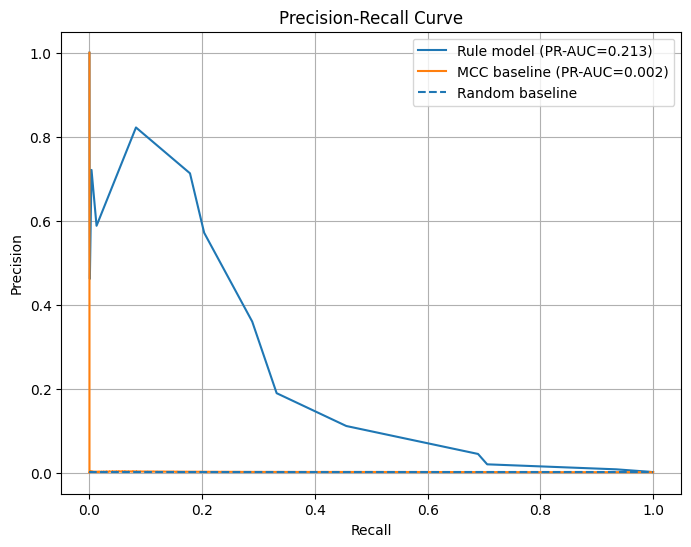

In [15]:
plt.figure(figsize=(8,6))

for col, name in [
    ("rule_score", "Rule model"),
    ("mcc_score", "MCC baseline")
]:

    precision, recall, _ = precision_recall_curve(
        results_no_ML["y_true"],
        results_no_ML[col]
    )

    pr_auc = average_precision_score(
        results_no_ML["y_true"],
        results_no_ML[col]
    )

    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

fraud_rate = results_no_ML["y_true"].mean()
plt.hlines(fraud_rate, 0, 1, linestyles="dashed", label="Random baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

Дадим бизнес-интерпретацию полученных моделей. Предположим, что каждый случай, когда модель помечает транзакцию как мошенническую, приводит к дополнительной проверке: сотрудники мониторингового отдела банка связываются с клиентом для подтверждения операции.

Модель типа «Всегда 0» пропускает все случаи мошенничества, но при этом не создаёт никакой дополнительной нагрузки на мониторинговый отдел.

Случайная модель создаёт небольшую нагрузку на отдел проверки, однако в данной выборке не выявляет ни одного реального случая мошенничества.

Модель на основе MCC и суммы транзакции на каждые 100 000 операций генерирует около 2065 сигналов, однако лишь примерно 6 из них оказываются реальными случаями мошенничества. При этом 116 мошеннических операций остаются незамеченными.

Эвристическая модель генерирует около 2456 сигналов, из которых 33 оказываются реальными мошенничествами, а 89 случаев остаются пропущенными.

Наилучший результат среди рассмотренных baseline моделей показывает модель риск-скоринга на основе правил. Она генерирует всего 98 сигналов, при этом примерно каждый третий сигнал соответствует реальному мошенничеству. Несмотря на то, что 87 случаев мошенничества остаются незамеченными (около двух третей), для системы, основанной исключительно на правилах, это является достаточно высоким результатом.

Итоговые показатели модели: PR-AUC = 0.2133, Precision = 0.3599, Recall = 0.2887.

В имеющейся документации указывалось, что минимально приемлемый уровень для работы системы составлял примерно Precision = 0.30 и Recall = 0.25. Полученные результаты соответствуют этим требованиям, что позволяет говорить о сопоставимом уровне эффективности с банковскими rule-based антифрод системами конца 1990-х — начала 2000-х годов.

Метрика PR-AUC в тот период практически не использовалась как стандартная метрика оценки, поэтому прямое историческое сравнение затруднено. Однако из открытых источников известно, что лучшие rule-based системы могли достигать значений Precision и Recall в диапазоне 0.30-0.40, но требовали постоянной корректировки и обновления правил экспертами.

Исходя из полученных результатов можно сделать несколько выводов.

В рамках условной бизнес-задачи данная rule-based система может рассматриваться как baseline, который должны превзойти модели машинного обучения.

Становится понятным, почему многие банки достаточно долго не внедряли ML-модели. Если модели машинного обучения давали лишь незначительное улучшение относительно экспертных систем, переход мог быть экономически неоправданным, учитывая необходимость модернизации инфраструктуры, тестирования, согласования с регуляторами и последующего сопровождения.

Для нашего проекта можно отметить, что используемые признаки содержат существенный предиктивный сигнал — иначе rule-based система не смогла бы показать столь высокий результат.

Таким образом, получена baseline модель для дальнейшего сравнения с ML-подходами со следующими показателями:

PR-AUC = 0.2133

Precision = 0.3599

Recall = 0.2887

F1 = 0.3204

In [16]:
# Сохраним результаты для дальнейшего сравнения с ML-моделями
results_no_ML.to_parquet("baseline_no_ML_results.parquet", index=False)
# Очистка переменных из памяти
for var in [
    'data', 'schema', 'train', 'test', 'y_train', 'y_test', 'y_pred_zero', 'fraud_rate', 'y_pred_random',
    'mcc_channel_fraud_mean_amount', 'mcc_fraud_mean_amount', 'mcc_channel_mean_test', 'mcc_mean_fallback',
    'mean_amount_test', 'multiplier', 'y_pred_baseline_3', 'y_score_baseline_3', 'global_fraud_rate', 'mean_amount',
    'candidate_features', 'risky_values', 'signals', 'y_pred_heuristic', 'results_threshold', 'threshold', 'flagged',
    'flagged_rate', 'df_threshold', 'y_pred', 'y_score', 'df_mcc_threshold', 'mcc_mean_test', 'risk_score_train',
    'best_f1', 'best_threshold', 'pred', 'f1', 'risk_score_test', 'y_pred_prob', 'y_pred_rule', 'data_linear',
    'predictions_dict', 'df_business_100k', 'name', 'precision', 'recall', 'pr_auc','col', 'dtype_str', 'f', 
    'fraud_rate_by_value', 't', 'thresholds', 'top_values','var', 'results_no_ML'
]:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

3667

## 4.2 Base-line модель на базе простой логистической регрессии

In [17]:
# Загружаем данные для линейной модели
data_linear = pd.read_parquet('data_linear.parquet')

with open('data_linear_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data_linear.columns:
        data_linear[col] = pd.to_datetime(data_linear[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data_linear.columns:
        data_linear[col] = data_linear[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data_linear.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data_linear[col] = data_linear[col].astype('string')
        else:
            data_linear[col] = data_linear[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

print(data_linear.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 56 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   Amount                               float32 
 1   Use_Chip                             int8    
 2   Is_Online                            int8    
 3   Merchant_State                       category
 4   MCC                                  int16   
 5   Fraud                                int8    
 6   Gender                               int8    
 7   Is_Apartment                         int8    
 8   Total_Debt                           float32 
 9   FICO                                 int16   
 10  Num_Credit_Cards                     int8    
 11  Card_Brand                           category
 12  Card_Type                            category
 13  Has_Chip                             int8    
 14  Cards_Issued                         int8    
 15  Credit_Limit 

In [18]:
# Делаем MCC категориальным признаком
data_linear['MCC'] = data_linear['MCC'].astype('category')

In [19]:
# Разбиваем на train, validate и test по времени в пропорции 70/15/15
train, test = train_test_split(data_linear, test_size=0.3, shuffle=False)
validate, test = train_test_split(test, test_size=0.5, shuffle=False)

In [20]:
# Подготовка данных для линейной модели
# Задаём целевую переменную
target_col = 'Fraud'
# Список категориальных признаков для OneHotEncoder
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]
# Список всех признаков кроме целевой переменной
feature_cols = [c for c in data_linear.columns if c != target_col]
# Список числовых признаков для StandardScaler
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Разделяем на X и y для train, validate и test
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]

# Создаём ColumnTransformer для числовых и категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Применяем трансформацию к train, validate и test
X_train_prepared = preprocessor.fit_transform(X_train)
X_validate_prepared = preprocessor.transform(X_validate)
X_test_prepared = preprocessor.transform(X_test)

# Проверяем размеры подготовленных данных
print('X_train_prepared:', X_train_prepared.shape)
print('X_validate_prepared:', X_validate_prepared.shape)
print('X_test_prepared:', X_test_prepared.shape)


num_cols: 51
cat_cols: 4
X_train_prepared: (16199551, 381)
X_validate_prepared: (3471333, 381)
X_test_prepared: (3471333, 381)


In [21]:
simple_logreg_model = LogisticRegression(random_state=42)
simple_logreg_model.fit(X_train_prepared, y_train)
# Предсказания на validate
y_validate_prob_simple_logreg = simple_logreg_model.predict_proba(X_validate_prepared)[:, 1]
y_validate_pred_simple_logreg = (y_validate_prob_simple_logreg >= 0.5).astype(int)
# Оцениваем на validate
add_result_prob('Простая логистическая регрессия(без подбора гиперпараметров) на валидации', y_validate, y_validate_prob_simple_logreg, threshold=0.5)
show_results()


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


In [22]:
# Посмотрим на важность признаков в модели. 

# Получаем имена признаков после трансформации
feature_names = preprocessor.get_feature_names_out()

# Получаем коэффициенты логистической регрессии
coefficients = simple_logreg_model.coef_[0]

# Создаём таблицу признаков и коэффициентов
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Добавим абсолютное значение коэффициента
coef_df['abs_coef'] = coef_df['coefficient'].abs()

# Топ признаков увеличивающих вероятность fraud
top_fraud = coef_df.sort_values('coefficient', ascending=False).head(20)

# Топ признаков уменьшающих вероятность fraud
top_nonfraud = coef_df.sort_values('coefficient').head(20)

print("ТОП-20 признаков увеличивающих шанс мошенничества:")
display(top_fraud[['feature','coefficient']])

print("ТОП-20 признаков уменьшающих шанс мошенничества:")
display(top_nonfraud[['feature','coefficient']])

ТОП-20 признаков увеличивающих шанс мошенничества:


,feature,coefficient
315,cat__MCC_4829,3.556777
326,cat__MCC_5310,2.481288
337,cat__MCC_5719,2.356894
2,num__Is_Online,1.589565
191,cat__Merchant_State_OH,1.561476
319,cat__MCC_5094,1.369002
325,cat__MCC_5300,1.167055
346,cat__MCC_5912,1.061469
339,cat__MCC_5732,1.045076
367,cat__MCC_7832,0.860842


ТОП-20 признаков уменьшающих шанс мошенничества:


,feature,coefficient
313,cat__MCC_4784,-7.668796
307,cat__MCC_4121,-4.561849
354,cat__MCC_6300,-3.988708
316,cat__MCC_4899,-3.150546
317,cat__MCC_4900,-2.432785
269,cat__Card_Type_Credit,-2.338381
270,cat__Card_Type_Debit,-1.951937
314,cat__MCC_4814,-1.813718
312,cat__MCC_4722,-1.763325
266,cat__Card_Brand_Discover,-1.681575


Мы видим, что в топ-признаки вошли "опасные" MCC и статус "он-лайн" платежа.

In [23]:
simple_logreg_model.intercept_

array([-5.95459136])

## 4.3 Усовершенствование моделей логистической регрессии

In [24]:
# Попробуем сделать таблицу менее разреженной. Уберем MCC признаки
cat_cols_no_mcc = [col for col in cat_cols if col != 'MCC']
preprocessor_no_mcc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_no_mcc)
    ],
    remainder='drop'
)
X_train_prepared_no_mcc = preprocessor_no_mcc.fit_transform(X_train)
X_validate_prepared_no_mcc = preprocessor_no_mcc.transform(X_validate)
X_test_prepared_no_mcc = preprocessor_no_mcc.transform(X_test)

# Строим модель
simple_logreg_model_no_mcc = LogisticRegression(random_state=42)
simple_logreg_model_no_mcc.fit(X_train_prepared_no_mcc, y_train)
# Предсказания на validate
y_validate_prob_simple_logreg_no_mcc = simple_logreg_model_no_mcc.predict_proba(X_validate_prepared_no_mcc)[:, 1]
y_validate_pred_simple_logreg_no_mcc = (y_validate_prob_simple_logreg_no_mcc >= 0.5).astype(int)
# Оцениваем на validate
add_result_prob('Простая логистическая регрессия (без MCC) на валидации', y_validate, y_validate_prob_simple_logreg_no_mcc, threshold=0.5)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


Как видим, показатели сразу сильно упали.

In [25]:
# Освободим память от не удачного экмперимента.
for var in ['cat_cols_no_mcc', 'preprocessor_no_mcc', 'X_train_prepared_no_mcc', 'X_validate_prepared_no_mcc', 'X_test_prepared_no_mcc',
            'simple_logreg_model_no_mcc', 'y_validate_prob_simple_logreg_no_mcc', 'y_validate_pred_simple_logreg_no_mcc'
    ]:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

115

Threshold: 0.10, Precision: 0.3230, Recall: 0.5792, F1: 0.4148, PR-AUC: 0.5016
Threshold: 0.15, Precision: 0.4423, Recall: 0.5267, F1: 0.4808, PR-AUC: 0.5016
Threshold: 0.20, Precision: 0.5421, Recall: 0.4877, F1: 0.5134, PR-AUC: 0.5016
Threshold: 0.25, Precision: 0.6131, Recall: 0.4537, F1: 0.5215, PR-AUC: 0.5016
Threshold: 0.30, Precision: 0.6770, Recall: 0.4247, F1: 0.5219, PR-AUC: 0.5016
Threshold: 0.35, Precision: 0.7300, Recall: 0.4022, F1: 0.5186, PR-AUC: 0.5016
Threshold: 0.40, Precision: 0.7636, Recall: 0.3799, F1: 0.5074, PR-AUC: 0.5016
Threshold: 0.45, Precision: 0.7959, Recall: 0.3614, F1: 0.4971, PR-AUC: 0.5016
Threshold: 0.50, Precision: 0.8282, Recall: 0.3451, F1: 0.4872, PR-AUC: 0.5016
Threshold: 0.55, Precision: 0.8518, Recall: 0.3277, F1: 0.4733, PR-AUC: 0.5016
Threshold: 0.60, Precision: 0.8737, Recall: 0.3049, F1: 0.4521, PR-AUC: 0.5016
Threshold: 0.65, Precision: 0.8869, Recall: 0.2817, F1: 0.4276, PR-AUC: 0.5016
Threshold: 0.70, Precision: 0.9151, Recall: 0.2685, 

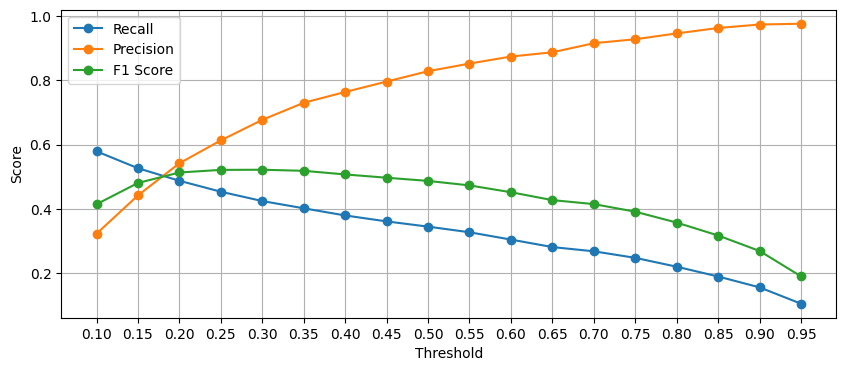

In [26]:
# Подберем оптимальный порог для логистической регрессии на validate
thresholds = np.arange(0.1, 1, 0.05)
y_validate_proba = simple_logreg_model.predict_proba(X_validate_prepared)[:, 1]
recall_scores, precision_scores, f1_scores = [], [], []
for threshold in thresholds:
    y_validate_pred = (y_validate_proba >= threshold).astype(int)
    recall_scores.append(recall_score(y_validate, y_validate_pred))
    precision_scores.append(precision_score(y_validate, y_validate_pred, zero_division=0))
    f1_scores.append(f1_score(y_validate, y_validate_pred, zero_division=0))
    auc_pr = average_precision_score(y_validate, y_validate_proba) # PR-AUC не зависит от порога, так что можно считать один раз, но для наглядности я оставил внутри цикла
    print(f"Threshold: {threshold:.2f}, Precision: {precision_scores[-1]:.4f}, Recall: {recall_scores[-1]:.4f}, F1: {f1_scores[-1]:.4f}, PR-AUC: {auc_pr:.4f}")
    
# Визуализируем Precision-Recall кривую
fix, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, recall_scores, label='Recall', marker='o')
ax.plot(thresholds, precision_scores, label='Precision', marker='o')
ax.plot(thresholds, f1_scores, label='F1 Score', marker='o')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_xticks(thresholds)
ax.grid()
ax.legend()


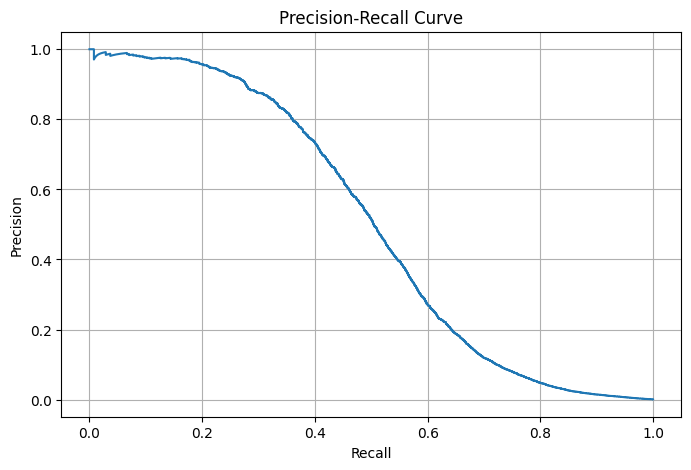

In [27]:
# Построим Precision-Recall кривую для лучшего порога
precision, recall, thresholds = precision_recall_curve(
    y_validate,
    y_validate_proba
)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [28]:
if False:
    # Перез запуском GridSearchCV и более сложных моделей освободим память от данных для линейной модели, которые нам больше не нужны.
    del data_linear, X_train, X_validate, X_test
    gc.collect()

In [29]:
# Подберем гиперпараметры для логистической регрессии с помощью GridSearchCV и TimeSeriesSplit
# TimeSeriesSplit сохраняет порядок строк и не перемешивает данные
if False: # В ходе работы выполнил этот код, это заняла существенное время и результат показал, что самая оптимальная модель - стандартная, без регуляризации
    # Отмечу, что в разумное время не удалось провести даже одну итерацию saga-солвера (даже на более мощном ПК со 128 гб памяти и 16 ядрами) мне пришлось
    # остановить задачу через 8 часов без результатов, так что пришлось ограничиться lbfgs-солвером и более узким набором гиперпараметров.
    # Проблема в том, что saga-солвер на большом числе признаков не масштабируется (процессор был загружен на 12%).
    tscv = TimeSeriesSplit(n_splits=3)

    param_grid = {
        'C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
        'class_weight': [None, 'balanced']
    }

    base_model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        max_iter=300,
        random_state=42
    )

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='average_precision',
        cv=tscv,
        n_jobs=3,
        pre_dispatch=3,
        verbose=2,
        refit=True,
        return_train_score=False
    )

    grid.fit(X_train_prepared, y_train)

    print("Лучшие гиперпараметры:", grid.best_params_)
    print("Лучший PR-AUC:", grid.best_score_)

In [30]:
if False: # Продолжение кода прошлой ячейки, который не был выполнен из-за долгого времени обучения
    best_model = grid.best_estimator_

    y_validate_proba = best_model.predict_proba(X_validate_prepared)[:,1]

    print(
    "Validate PR-AUC:",
    average_precision_score(y_validate, y_validate_proba)
    )

Для справки - были получены такие результаты.
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Лучшие гиперпараметры: {'C': 1.0, 'class_weight': None} 
Лучший PR-AUC: 0.23486783767748076
Validate PR-AUC: 0.5015666370147961
Нам не очень подходит GridSearchCV т.к. он использует фолды, а при дисбалансе классов это может приводить к тому, что на некоторых фолдах мало целеых признаков и сама модель в целом работает не стабильно. Откажемся от GridSearchCV в пользу ручного перебора с использованием валидационной выборки.

In [31]:
# Переберем параметры вручную т.к. GridSearchCV с TimeSeriesSplit работает довольно долго, а у нас всего 12 комбинаций параметров + мы будем
# проверять результаты  на validate, а не на фолдах.

param_grid = [
    {'C': 0.03, 'class_weight': None},
    {'C': 0.03, 'class_weight': 'balanced'},
    {'C': 0.1, 'class_weight': None},
    {'C': 0.1, 'class_weight': 'balanced'},
    {'C': 0.3, 'class_weight': None},
    {'C': 0.3, 'class_weight': 'balanced'},
    {'C': 1.0, 'class_weight': None},
    {'C': 1.0, 'class_weight': 'balanced'},
    {'C': 3.0, 'class_weight': None},
    {'C': 3.0, 'class_weight': 'balanced'},
    {'C': 10.0, 'class_weight': None},
    {'C': 10.0, 'class_weight': 'balanced'},
]

results_logreg_param_search = []

for i, params in enumerate(param_grid, 1):

    print(f"\n========== ITERATION {i}/{len(param_grid)} ==========")
    print("Params:", params)

    start_time = time.time()

    model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        max_iter=300,
        random_state=42,
        C=params['C'],
        class_weight=params['class_weight']
    )

    # обучение
    fit_start = time.time()
    model.fit(X_train_prepared, y_train)
    fit_time = time.time() - fit_start

    # предсказание
    pred_start = time.time()
    y_val_proba = model.predict_proba(X_validate_prepared)[:,1]
    pred_time = time.time() - pred_start

    y_val_pred = (y_val_proba >= 0.5).astype(int)

    pr_auc = average_precision_score(y_validate, y_val_proba)
    roc_auc = roc_auc_score(y_validate, y_val_proba)
    precision = precision_score(y_validate, y_val_pred, zero_division=0)
    recall = recall_score(y_validate, y_val_pred, zero_division=0)
    f1 = f1_score(y_validate, y_val_pred, zero_division=0)

    total_time = time.time() - start_time

    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"ROC-AUC: {roc_auc:.6f}")
    print(f"Precision@0.5: {precision:.4f}")
    print(f"Recall@0.5: {recall:.4f}")
    print(f"F1@0.5: {f1:.4f}")
    print(f"Fit time: {fit_time:.2f} sec")
    print(f"Predict time: {pred_time:.2f} sec")
    print(f"Total iteration time: {total_time:.2f} sec")

    results_logreg_param_search.append({
        'C': params['C'],
        'class_weight': params['class_weight'],
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'precision_05': precision,
        'recall_05': recall,
        'f1_05': f1,
        'fit_time_sec': fit_time
    })

results_df = pd.DataFrame(results_logreg_param_search).sort_values('pr_auc', ascending=False)

print("\n====== FINAL RESULTS ======")
display(results_df)


========== ITERATION 1/12 ==========
Params: {'C': 0.03, 'class_weight': None}
PR-AUC: 0.439106
ROC-AUC: 0.966791
Precision@0.5: 0.9070
Recall@0.5: 0.2733
F1@0.5: 0.4200
Fit time: 52.62 sec
Predict time: 0.31 sec
Total iteration time: 54.63 sec

========== ITERATION 2/12 ==========
Params: {'C': 0.03, 'class_weight': 'balanced'}
PR-AUC: 0.292959
ROC-AUC: 0.975206
Precision@0.5: 0.0336
Recall@0.5: 0.9008
F1@0.5: 0.0647
Fit time: 249.92 sec
Predict time: 0.31 sec
Total iteration time: 252.04 sec

========== ITERATION 3/12 ==========
Params: {'C': 0.1, 'class_weight': None}
PR-AUC: 0.497982
ROC-AUC: 0.967878
Precision@0.5: 0.8593
Recall@0.5: 0.3248
F1@0.5: 0.4714
Fit time: 70.12 sec
Predict time: 0.32 sec
Total iteration time: 72.18 sec

========== ITERATION 4/12 ==========
Params: {'C': 0.1, 'class_weight': 'balanced'}
PR-AUC: 0.293344
ROC-AUC: 0.973358
Precision@0.5: 0.0335
Recall@0.5: 0.8980
F1@0.5: 0.0645
Fit time: 245.67 sec
Predict time: 0.50 sec
Total iteration time: 247.88 sec

=

,C,class_weight,pr_auc,roc_auc,precision_05,recall_05,f1_05,fit_time_sec
10,10,None,0.530368,0.961349,0.853372,0.348503,0.494898,89.232567
6,1,None,0.501567,0.967705,0.828161,0.34515,0.487236,77.941165
2,0.1,None,0.497982,0.967878,0.859316,0.32479,0.471406,70.117605
4,0.3,None,0.485762,0.966988,0.836976,0.339401,0.482958,65.799573
8,3,None,0.478713,0.967932,0.841088,0.333413,0.47753,66.899959
0,0.03,None,0.439106,0.966791,0.906995,0.273293,0.420026,52.619598
7,1,balanced,0.293556,0.973584,0.033386,0.899162,0.064382,257.020462
3,0.1,balanced,0.293344,0.973358,0.033455,0.897964,0.064506,245.670528
1,0.03,balanced,0.292959,0.975206,0.033573,0.900838,0.064733,249.923235
11,10,balanced,0.292661,0.972419,0.033415,0.896287,0.064429,253.367336


In [32]:
# Как мы видим, высокий C (меньше регуляризации) даёт наилучший результат.
# Попробуем посмотреть ещё большее увеличение. Балансировку классов делать не будем, так как она не дала улучшения.
param_grid = [

    {'C': 15.0, 'class_weight': None},
    {'C': 20.0, 'class_weight': None},
    {'C': 25.0, 'class_weight': None},
    {'C': 30.0, 'class_weight': None},
]

# results_logreg_param_search = [] - не будем обнулять результаты

for i, params in enumerate(param_grid, 1):

    print(f"\n========== ITERATION {i}/{len(param_grid)} ==========")
    print("Params:", params)

    start_time = time.time()

    model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        max_iter=300,
        random_state=42,
        C=params['C'],
        class_weight=params['class_weight']
    )

    # обучение
    fit_start = time.time()
    model.fit(X_train_prepared, y_train)
    fit_time = time.time() - fit_start

    # предсказание
    pred_start = time.time()
    y_val_proba = model.predict_proba(X_validate_prepared)[:,1]
    pred_time = time.time() - pred_start

    y_val_pred = (y_val_proba >= 0.5).astype(int)

    pr_auc = average_precision_score(y_validate, y_val_proba)
    roc_auc = roc_auc_score(y_validate, y_val_proba)
    precision = precision_score(y_validate, y_val_pred, zero_division=0)
    recall = recall_score(y_validate, y_val_pred, zero_division=0)
    f1 = f1_score(y_validate, y_val_pred, zero_division=0)

    total_time = time.time() - start_time

    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"ROC-AUC: {roc_auc:.6f}")
    print(f"Precision@0.5: {precision:.4f}")
    print(f"Recall@0.5: {recall:.4f}")
    print(f"F1@0.5: {f1:.4f}")
    print(f"Fit time: {fit_time:.2f} sec")
    print(f"Predict time: {pred_time:.2f} sec")
    print(f"Total iteration time: {total_time:.2f} sec")

    results_logreg_param_search.append({
        'C': params['C'],
        'class_weight': params['class_weight'],
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'precision_05': precision,
        'recall_05': recall,
        'f1_05': f1,
        'fit_time_sec': fit_time
    })

results_df = pd.DataFrame(results_logreg_param_search).sort_values('pr_auc', ascending=False)

print("\n====== FINAL RESULTS ======")
display(results_df)


========== ITERATION 1/4 ==========
Params: {'C': 15.0, 'class_weight': None}
PR-AUC: 0.535209
ROC-AUC: 0.966130
Precision@0.5: 0.8564
Recall@0.5: 0.3543
F1@0.5: 0.5012
Fit time: 92.83 sec
Predict time: 0.32 sec
Total iteration time: 94.92 sec

========== ITERATION 2/4 ==========
Params: {'C': 20.0, 'class_weight': None}
PR-AUC: 0.518871
ROC-AUC: 0.965236
Precision@0.5: 0.8081
Recall@0.5: 0.3631
F1@0.5: 0.5011
Fit time: 79.95 sec
Predict time: 0.30 sec
Total iteration time: 82.02 sec

========== ITERATION 3/4 ==========
Params: {'C': 25.0, 'class_weight': None}
PR-AUC: 0.506574
ROC-AUC: 0.962491
Precision@0.5: 0.8730
Recall@0.5: 0.3344
F1@0.5: 0.4835
Fit time: 76.59 sec
Predict time: 0.32 sec
Total iteration time: 78.71 sec

========== ITERATION 4/4 ==========
Params: {'C': 30.0, 'class_weight': None}
PR-AUC: 0.504382
ROC-AUC: 0.960541
Precision@0.5: 0.8751
Recall@0.5: 0.3322
F1@0.5: 0.4816
Fit time: 74.11 sec
Predict time: 0.30 sec
Total iteration time: 76.20 sec

====== FINAL RESULT

,C,class_weight,pr_auc,roc_auc,precision_05,recall_05,f1_05,fit_time_sec
12,15,None,0.535209,0.96613,0.856398,0.354251,0.501186,92.830015
10,10,None,0.530368,0.961349,0.853372,0.348503,0.494898,89.232567
13,20,None,0.518871,0.965236,0.808102,0.363114,0.501074,79.953196
14,25,None,0.506574,0.962491,0.873046,0.334371,0.483547,76.588717
15,30,None,0.504382,0.960541,0.875079,0.332216,0.481597,74.111259
6,1,None,0.501567,0.967705,0.828161,0.34515,0.487236,77.941165
2,0.1,None,0.497982,0.967878,0.859316,0.32479,0.471406,70.117605
4,0.3,None,0.485762,0.966988,0.836976,0.339401,0.482958,65.799573
8,3,None,0.478713,0.967932,0.841088,0.333413,0.47753,66.899959
0,0.03,None,0.439106,0.966791,0.906995,0.273293,0.420026,52.619598


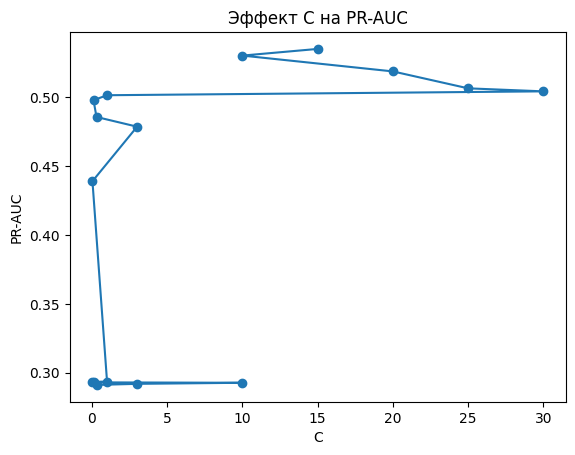

In [33]:
# Визуализируем зависимость PR-AUC от C
plt.plot(results_df['C'], results_df['pr_auc'], marker='o')
plt.xlabel("C")
plt.ylabel("PR-AUC")
plt.title("Эффект C на PR-AUC")
plt.show()

In [34]:
# Переподберем порог для лучшей модели на validate
# Возьмём С = 10 как стабильный средний вариант, показатель 15 выглядит анормальным на графике
best_C = 10
final_model_log_reg = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=best_C
)
final_model_log_reg.fit(X_train_prepared, y_train)
thresholds = np.arange(0.01, 0.99, 0.01)

results_threshold = []

y_validate_proba = final_model_log_reg.predict_proba(X_validate_prepared)[:,1]

for t in thresholds:

    y_pred = (y_validate_proba >= t).astype(int)

    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)

    results_threshold.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

thr_df = pd.DataFrame(results_threshold)
thr_df.sort_values("f1", ascending=False).head(20)

,threshold,precision,recall,f1
24,0.25,0.689057,0.457006,0.549539
23,0.24,0.676234,0.462754,0.549488
20,0.21,0.640665,0.48,0.548816
22,0.23,0.664622,0.467066,0.5486
21,0.22,0.652447,0.472575,0.548132
25,0.26,0.6967,0.45006,0.546857
19,0.2,0.626082,0.485269,0.546755
18,0.19,0.611642,0.490778,0.544585
26,0.27,0.705456,0.442874,0.544144
17,0.18,0.59628,0.499162,0.543416


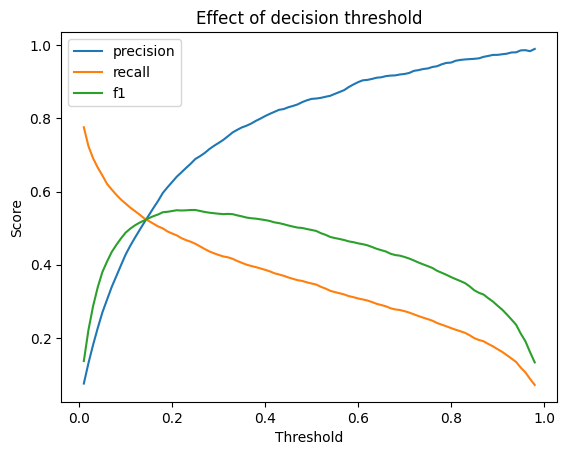

In [35]:
plt.plot(thr_df["threshold"], thr_df["precision"], label="precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="f1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Effect of decision threshold")
plt.show()

In [36]:
# Обучим модель с параметрами c=10 и threshold=0.25 на train и проверим на validate для референса
final_model_log_reg_val = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=10
)
final_model_log_reg_val.fit(X_train_prepared, y_train)
y_validate_proba_val = final_model_log_reg_val.predict_proba(X_validate_prepared)[:, 1]
add_result_prob(
    'Логистическая регрессия (с подобранными гиперпараметрами) на валидации',
    y_validate,
    y_validate_proba_val,
    threshold=0.25
)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.5304,0.9613,0.9991,0.6891,0.457,0.5495
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


In [37]:
# Финальное обучение на train + validate, тестирование на test

target_col = 'Fraud'

cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

feature_cols = [c for c in data_linear.columns if c != target_col]
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Объединяем train и validate
X_train_final = pd.concat([X_train, X_validate], axis=0)
y_train_final = pd.concat([y_train, y_validate], axis=0)

# Используем уже существующий test
X_test_final = X_test.copy()
y_test_final = y_test.copy()

# Заново обучаем preprocessing на train+validate
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

X_train_final_prepared = preprocessor.fit_transform(X_train_final)
X_test_final_prepared = preprocessor.transform(X_test_final)

print('X_train_final_prepared:', X_train_final_prepared.shape)
print('X_test_final_prepared:', X_test_final_prepared.shape)

# Для референса обучим baseline-модель
simple_logreg_model_train_validate = LogisticRegression(random_state=42)
simple_logreg_model_train_validate.fit(X_train_final_prepared, y_train_final)

y_test_prob_simple_logreg = simple_logreg_model_train_validate.predict_proba(X_test_final_prepared)[:, 1]

add_result_prob(
    'Логистическая регрессия (без подбора гиперпараметров) на тесте',
    y_test_final,
    y_test_prob_simple_logreg,
    threshold=0.5
)

# Финальная tuned-модель
best_C = 10
best_threshold = 0.25

final_model_log_reg = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=best_C
)

final_model_log_reg.fit(X_train_final_prepared, y_train_final)

y_test_proba = final_model_log_reg.predict_proba(X_test_final_prepared)[:, 1]

add_result_prob(
    'Логистическая регрессия (после подбора гиперпараметров) на тесте',
    y_test_final,
    y_test_proba,
    threshold=best_threshold
)

show_results()

num_cols: 51
cat_cols: 4
X_train_final_prepared: (19670884, 386)
X_test_final_prepared: (3471333, 386)


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.5304,0.9613,0.9991,0.6891,0.457,0.5495
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
9,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.3973,0.981,0.9988,0.5515,0.3574,0.4337
8,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.3871,0.9797,0.999,0.7639,0.2607,0.3887
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


На данный момент мы можем показать, что ML однозначно превосходит любые системы, основанные на правилах. Базовая модель без подбора гиперпараметров уже существенно превосходила эвристические и rule-based подходы. Подбор коэффициента регуляризации и порога классификации позволил дополнительно улучшить качество модели по метрикам PR-AUC, Recall и F1.

На валидационной выборке лучшая модель достигла PR-AUC 0.5304 и F1 0.5495. На тестовой выборке качество снизилось до PR-AUC 0.3973 и F1 0.4337, что может быть связано с тем, что порог для определения мошенничества может меняться со временем. Это основная проблема логистической регрессии - мы вынуждены искать оптимальный порог, который, однако, постоянно меняется в зависимости от текущей тенденции. В конечном итоге порог для логистической регрессии определяется бизнес-процессом: заказчик должен решить, сколько "ложных" срабатываний допустимо (каждое ложное срабатывание - нагрузка на персонал банка), а сколько мошеннических транзакций банк готов "пропустить".

## 4.4 Логистическая регрессия на полиномиальных признаках

In [ ]:
# Для модели на полиномиальных признаках может понадобится много памяти - очистим память от всех переменных. 
# Все они занимают значительный объём ОЗУ, лучше будем по мере необходимости считывать их заново.
# Сохраняем только result т.к. в ней наша табличка для сравнения.
for var in [
    "GridSearchCV", "TimeSeriesSplit", "X_test", "X_test_final", "X_test_final_prepared", "X_test_prepared",
    "X_train", "X_train_final", "X_train_final_prepared", "X_train_prepared", "X_validate", "X_validate_prepared", "auc_pr", "ax",
    "best_C", "best_threshold", "cat_cols", "coef_df", "coefficients", "col", "data_linear", "dtype_str", "f", "f1", "f1_scores",
    "feature_cols", "feature_names", "final_model_log_reg", "final_model_log_reg_val", "fit_start", "fit_time", "fix", "i", "model",
    "num_cols", "param_grid", "params", "pr_auc", "precision", "precision_scores", "pred_start", "pred_time", "preprocessor",
    "recall", "recall_scores", "results_df", "results_logreg_param_search", "results_threshold", "roc_auc", "schema",
    "simple_logreg_model", "simple_logreg_model_train_validate", "start_time", "t", "target_col", "test", "thr_df", "threshold",
    "thresholds", "top_fraud", "top_nonfraud", "total_time", "train", "validate", "var", "y_pred", "y_test", "y_test_final",
    "y_test_prob_simple_logreg", "y_test_proba", "y_train", "y_train_final", "y_val_pred", "y_val_proba", "y_validate",
    "y_validate_pred", "y_validate_pred_simple_logreg", "y_validate_prob_simple_logreg", "y_validate_proba", "y_validate_proba_val"
]:
    if var in locals():
        del locals()[var]
    elif var in globals():
        del globals()[var]
        
gc.collect()
# На моём ПК освободилось более 15гб ОЗУ

3549

Нам необходимо определить предел возможностей линейных моделей. Попробуем создать модель на полиномиальных признаках и посмотреть, даёт ли это улучшение модели. 

In [39]:
# Загружаем данные для линейной модели
data_linear = pd.read_parquet('data_linear.parquet')

with open('data_linear_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data_linear.columns:
        data_linear[col] = pd.to_datetime(data_linear[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data_linear.columns:
        data_linear[col] = data_linear[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data_linear.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data_linear[col] = data_linear[col].astype('string')
        else:
            data_linear[col] = data_linear[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

# Делаем MCC категориальным признаком
data_linear['MCC'] = data_linear['MCC'].astype('category')
# Разбиваем на train, validate и test по времени в пропорции 70/15/15
train, test = train_test_split(data_linear, test_size=0.3, shuffle=False)
validate, test = train_test_split(test, test_size=0.5, shuffle=False)

In [40]:
train.tail()

,Amount,Use_Chip,Is_Online,Merchant_State,MCC,Fraud,Gender,Is_Apartment,Total_Debt,FICO,Num_Credit_Cards,Card_Brand,Card_Type,Has_Chip,Cards_Issued,Credit_Limit,txn_month,txn_day,account_age_months,card_expiry_months,Amount_to_Income,Error_Bad_CVV,Error_Bad_Card_Number,Error_Bad_Expiration,Error_Bad_PIN,Error_Bad_Zipcode,Error_Insufficient_Balance,Error_Technical_Glitch,user_age,is_night,is_business_hours,amount_log,amount_round_10,time_since_prev_txn_card_min,time_since_prev_txn_user_min,txn_gap_bin,first_user_payment_to_this_merchant,txn_count_5m_card,txn_count_1h_card,txn_count_5m_user,txn_count_1h_user,state_changed_1d,errors_prev_1h,merchant_txn_count_1h,hour_sin,hour_cos,dow_sin,dow_cos,merchant_velocity_ratio_log,card_burst_5m,merchant_fraud_count,merchant_fraud_rate,state_fraud_count,state_fraud_rate,prev_not_foreign_card,is_foreign_offline
16199546,24.59,0,1,NaN,4814,0,0,0,106266,684,4,Visa,Debit,1,2,54128,12,15,88,3,0.002785,0,0,0,0,0,0,0,27,0,0,3.242202,0,522,41,6,0,1,1,1,1,1,0,1,0.965926,-0.258819,0.781832,0.62349,-3.258096,0,74,0.000666,0,0,1,0
16199547,52,1,0,FL,5541,0,1,0,132409,602,1,Mastercard,Debit,1,2,18627,12,15,140,85,0.011877,0,0,0,0,0,0,0,50,0,0,3.970292,0,24,24,4,0,1,1,1,1,0,0,2,0.965926,-0.258819,0.781832,0.62349,-2.87168,0,18,0.000109,280,0.000278,1,0
16199548,59.889999,0,1,NaN,7349,0,1,1,149587,728,4,Mastercard,Debit (Prepaid),1,2,79,12,15,72,62,0.012777,0,0,0,0,0,0,0,33,0,0,4.109069,0,41,41,5,0,1,1,1,1,1,0,2,0.965926,-0.258819,0.781832,0.62349,-2.890372,0,4,0.00023,0,0,0,0
16199549,23.68,0,0,MD,5942,0,0,1,92489,820,5,Visa,Debit,0,1,18138,12,15,9,86,0.006035,0,0,0,0,0,0,0,63,0,0,3.205993,0,1376,918,6,0,1,2,1,2,0,0,3,0.965926,-0.258819,0.781832,0.62349,-2.621039,0,78,0.000269,78,0.00031,1,0
16199550,32.740002,1,0,KY,4121,0,0,1,102286,672,3,Mastercard,Credit,1,2,11200,12,15,64,92,0.007629,0,0,0,0,0,0,0,32,0,0,3.518684,0,608,61,6,0,1,2,1,2,1,0,4,0.965926,-0.258819,0.781832,0.62349,-2.415914,0,0,0,36,0.00016,0,0


In [43]:
# Целевая переменная
target_col = 'Fraud'

# Категориальные признаки
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

# Числовые признаки, для которых строим полиномиальные признаки
poly_cols = [
    'Amount',
    'amount_log',
    'time_since_prev_txn_card_min',
    'time_since_prev_txn_user_min',
    'merchant_velocity_ratio_log',
    'merchant_fraud_rate',
    'state_fraud_rate'
]

# Все признаки кроме target
feature_cols = [c for c in data_linear.columns if c != target_col]

# Оставшиеся числовые признаки без полиномиального расширения
num_cols = [c for c in feature_cols if c not in cat_cols and c not in poly_cols]

print('cat_cols:', len(cat_cols))
print('poly_cols:', len(poly_cols))
print('num_cols:', len(num_cols))

# X / y
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]

# Pipeline для полиномиальных признаков
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Pipeline для обычных числовых
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Общий препроцессинг
preprocessor_poly_selected = ColumnTransformer(
    transformers=[
        ('poly_num', poly_pipeline, poly_cols),
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Преобразуем данные
X_train_prepared_poly_selected = preprocessor_poly_selected.fit_transform(X_train)
X_validate_prepared_poly_selected = preprocessor_poly_selected.transform(X_validate)
X_test_prepared_poly_selected = preprocessor_poly_selected.transform(X_test)

print('X_train_prepared_poly_selected:', X_train_prepared_poly_selected.shape)
print('X_validate_prepared_poly_selected:', X_validate_prepared_poly_selected.shape)
print('X_test_prepared_poly_selected:', X_test_prepared_poly_selected.shape)

# Простая логистическая регрессия без подбора параметров
poly_selected_logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

poly_selected_logreg.fit(X_train_prepared_poly_selected, y_train)

# Предсказания на validate
y_validate_proba_poly_selected = poly_selected_logreg.predict_proba(
    X_validate_prepared_poly_selected
)[:, 1]

y_validate_pred_poly_selected = (y_validate_proba_poly_selected >= 0.5).astype(int)

    
# Метрики
print('Результаты модели с полиномиальными признаками для отдельных стобцов на validate:')
print('PR-AUC:', average_precision_score(y_validate, y_validate_proba_poly_selected))
print('ROC-AUC:', roc_auc_score(y_validate, y_validate_proba_poly_selected))
print('Precision@0.5:', precision_score(y_validate, y_validate_pred_poly_selected, zero_division=0))
print('Recall@0.5:', recall_score(y_validate, y_validate_pred_poly_selected, zero_division=0))
print('F1@0.5:', f1_score(y_validate, y_validate_pred_poly_selected, zero_division=0))

cat_cols: 4
poly_cols: 7
num_cols: 44
X_train_prepared_poly_selected: (16199551, 409)
X_validate_prepared_poly_selected: (3471333, 409)
X_test_prepared_poly_selected: (3471333, 409)


c:\Users\dmytr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Результаты модели с полиномиальными признаками для отдельных стобцов на validate:
PR-AUC: 0.34816913939108896
ROC-AUC: 0.9572582531684228
Precision@0.5: 0.655448717948718
Recall@0.5: 0.2938922155688623
F1@0.5: 0.40582106829832976


In [45]:
# Побираем порог для лучшей модели на validate
thresholds = np.arange(0.01, 0.99, 0.01)
results_threshold_poly_selected = []
for t in thresholds:

    y_pred = (y_validate_proba_poly_selected >= t).astype(int)

    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)

    results_threshold_poly_selected.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })
thr_poly_selected_df = pd.DataFrame(results_threshold_poly_selected)
thr_poly_selected_df.sort_values("f1", ascending=False).head(20)


,threshold,precision,recall,f1
39,0.4,0.53876,0.332934,0.411547
40,0.41,0.549539,0.328144,0.410918
41,0.42,0.561695,0.323832,0.410817
38,0.39,0.523031,0.337246,0.410077
43,0.44,0.584738,0.315689,0.410017
45,0.46,0.606958,0.309222,0.409711
47,0.48,0.633083,0.302515,0.4094
42,0.43,0.571306,0.318563,0.409042
44,0.45,0.594694,0.311377,0.408741
37,0.38,0.510409,0.340599,0.408562


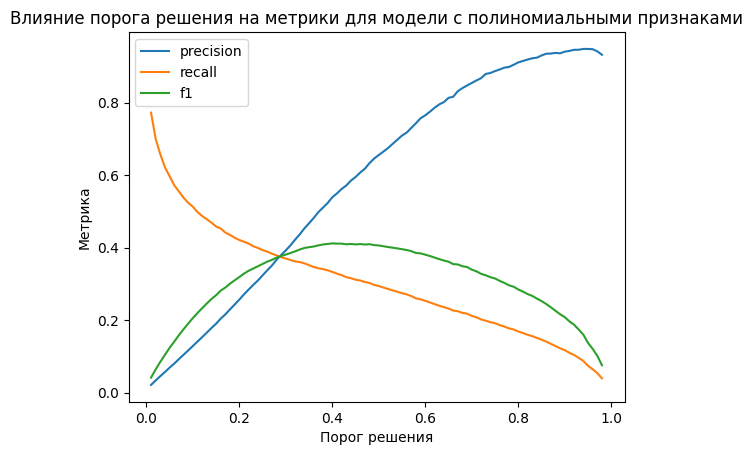

In [46]:
# График зависимости метрик от порога для модели с полиномиальными признаками
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["precision"], label="precision")
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["recall"], label="recall")
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["f1"], label="f1")
plt.xlabel("Порог решения")
plt.ylabel("Метрика") 
plt.legend()
plt.title("Влияние порога решения на метрики для модели с полиномиальными признаками")
plt.show()

In [47]:
# Смотрим результат
y_validate_proba = poly_selected_logreg.predict_proba(X_validate_prepared_poly_selected)[:, 1]

add_result_prob(
    'Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации',
    y_validate,
    y_validate_proba,
    threshold=0.4
)

show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.5304,0.9613,0.9991,0.6891,0.457,0.5495
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
9,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.3973,0.981,0.9988,0.5515,0.3574,0.4337
8,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.3871,0.9797,0.999,0.7639,0.2607,0.3887
10,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.3482,0.9573,0.9989,0.5388,0.3329,0.4115
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017


Как видим, полиномиальные признаки не помогли улучшить модель. Т.е. полиномиальные взаимодействия оказались бесполезны для точности предсказания. Скорее всего это связано тем, что мы и так создали много хороших признаков взаимодействия, а полиномиальные признаки только внесли шум. Мы не будем проверять её на тесте т.к. при таком падении результатов на валидации очевидно, что тест даст результат ещё хуже.

In [48]:
# Снова чистим память перед последним этапом
for var in [
    "data_linear", "schema", "target_col", "cat_cols", "feature_cols", "num_cols",
    "X_train", "X_validate", "X_test", "y_train", "y_validate", "y_test", "poly_pipeline", "num_pipeline",
    "preprocessor_poly_selected", "X_train_prepared_poly_selected", "X_validate_prepared_poly_selected", "X_test_prepared_poly_selected",
    "poly_selected_logreg", "y_validate_proba_poly_selected", "y_validate_pred_poly_selected", "thresholds",
    "results_threshold_poly_selected", "thr_poly_selected_df", "y_validate_proba", "y_pred"
]:
    if var in locals():
        del locals()[var]
    elif var in globals():
        del globals()[var]
import gc
gc.collect()

3666

## 4.5 Уменьшение размерности в антифрод-анализе

На финальном этапе работы с линейными моделями мы попробуем проверить, помогает ли уменьшение размерности лучше предсказывать мошеннические транзакции.
Теория состоит в том, что если оставшиеся признаки будут объяснять 95% дисперсии и при этом их будет существенно меньше - качество модели не ухудшится.

In [49]:
# Целевая переменная
target_col = 'Fraud'

# Категориальные признаки
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

# Все признаки кроме target
feature_cols = [c for c in train.columns if c != target_col]

# Числовые признаки
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Разделяем на X и y для train, validate и test
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]


# Пайплайн для числовых признаков
num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)) # сохраняем 95% дисперсии
])

# Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Общий препроцессор
preprocessor_pca_ohe = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    remainder='drop'
)

# fit только на train
X_train_pca_ohe = preprocessor_pca_ohe.fit_transform(X_train, y_train)

# transform на validate и test
X_validate_pca_ohe = preprocessor_pca_ohe.transform(X_validate)
X_test_pca_ohe = preprocessor_pca_ohe.transform(X_test)

print("Изначальные признаки:", X_train.shape[1])
print("Признаки после PCA + OHE:", X_train_pca_ohe.shape[1])

# Информация по PCA
pca_model = preprocessor_pca_ohe.named_transformers_['num'].named_steps['pca']
print("Количество PCA-компонент:", pca_model.n_components_)
print("Суммарная объяснённая дисперсия:", pca_model.explained_variance_ratio_.sum())

# Обучаем логистическую регрессию на данных после PCA и OHE

logreg_pca_ohe = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

logreg_pca_ohe.fit(X_train_pca_ohe, y_train)

# Оценка на validate

y_validate_proba = logreg_pca_ohe.predict_proba(X_validate_pca_ohe)[:, 1]
y_validate_pred = logreg_pca_ohe.predict(X_validate_pca_ohe)

validate_metrics = {
    'PR-AUC': average_precision_score(y_validate, y_validate_proba),
    'ROC-AUC': roc_auc_score(y_validate, y_validate_proba),
    'Accuracy': accuracy_score(y_validate, y_validate_pred),
    'Precision': precision_score(y_validate, y_validate_pred, zero_division=0),
    'Recall': recall_score(y_validate, y_validate_pred, zero_division=0),
    'F1': f1_score(y_validate, y_validate_pred, zero_division=0)
}

print('\nМетрики на validate:')
for metric_name, metric_value in validate_metrics.items():
    print(f'{metric_name}: {metric_value:.4f}')

# Подбираем оптимальный порог для модели с PCA + OHE
thresholds = np.arange(0.01, 0.99, 0.01)
results_threshold_pca_ohe = []
for t in thresholds:
    y_pred = (y_validate_proba >= t).astype(int)
    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)
    results_threshold_pca_ohe.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })
    
thr_pca_ohe_df = pd.DataFrame(results_threshold_pca_ohe)
thr_pca_ohe_df.sort_values("f1", ascending=False).head(20)



num_cols: 51
cat_cols: 4
Изначальные признаки: 55
Признаки после PCA + OHE: 375
Количество PCA-компонент: 45
Суммарная объяснённая дисперсия: 0.9588647095843982

Метрики на validate:
PR-AUC: 0.2200
ROC-AUC: 0.9634
Accuracy: 0.9676
Precision: 0.0322
Recall: 0.8920
F1: 0.0621


,threshold,precision,recall,f1
97,0.98,0.255239,0.45509,0.327051
96,0.97,0.200279,0.516647,0.288658
95,0.96,0.164552,0.568383,0.255216
94,0.95,0.137417,0.606707,0.22408
93,0.94,0.118626,0.63018,0.199666
92,0.93,0.105277,0.65509,0.181402
91,0.92,0.096387,0.681198,0.168879
90,0.91,0.088432,0.697246,0.156957
89,0.9,0.082531,0.712096,0.147918
88,0.89,0.077659,0.72503,0.140292


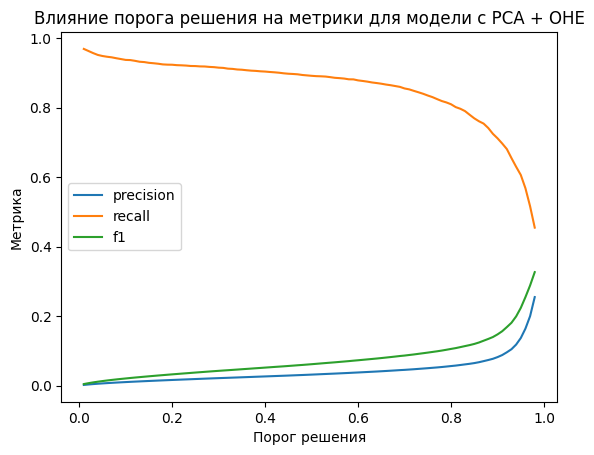

In [50]:
# Строми график завимисоти метрик от порога для модели с PCA + OHE
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["precision"], label="precision")
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["recall"], label="recall")
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["f1"], label="f1")
plt.xlabel("Порог решения")
plt.ylabel("Метрика")
plt.legend()
plt.title("Влияние порога решения на метрики для модели с PCA + OHE")
plt.show()


Как видим, оптимальной точки графики вообще не имеют. Возьмем максимальный f1, но уже очевидно, что экмперимент не удачный.

In [51]:
# Делаем предсказание на валидации для референса
add_result_prob(
    'Логистическая регрессия (с PCA + OHE) на валидации',
    y_validate,
    y_validate_proba,
    threshold=0.98
)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.5304,0.9613,0.9991,0.6891,0.457,0.5495
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
9,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.3973,0.981,0.9988,0.5515,0.3574,0.4337
8,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.3871,0.9797,0.999,0.7639,0.2607,0.3887
10,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.3482,0.9573,0.9989,0.5388,0.3329,0.4115
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
11,Логистическая регрессия (с PCA + OHE) на валидации,0.22,0.9634,0.9977,0.2552,0.4551,0.3271
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058


In [52]:
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.5304,0.9613,0.9991,0.6891,0.457,0.5495
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.5016,0.9677,0.9991,0.8282,0.3451,0.4872
9,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.3973,0.981,0.9988,0.5515,0.3574,0.4337
8,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.3871,0.9797,0.999,0.7639,0.2607,0.3887
10,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.3482,0.9573,0.9989,0.5388,0.3329,0.4115
6,Простая логистическая регрессия (без MCC) на валидации,0.2909,0.9456,0.9989,0.6761,0.2299,0.3432
11,Логистическая регрессия (с PCA + OHE) на валидации,0.22,0.9634,0.9977,0.2552,0.4551,0.3271
4,Риск-скор на основе правил,0.2133,0.9506,0.9985,0.3599,0.2887,0.3204
3,Эвристика на глаз,0.0046,0.624,0.9749,0.0136,0.2722,0.0259
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058


Вывод - методы уменьшения размерности приводят к существенной потере предсказательной способности модели. Это вызвано тем, что в подобных моделях множество признаков даёт достаточно слабые сигналы, без которых модель не может эффективно работать. Более того, мы сократили всего 10 признаков, что не является существенным. Таким образом в уменьшении размерности для данного датасета нет смысла.

In [53]:
# Сохраним список результатов
with open('results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

## 4.6 Выводы

Мы проанализировали базовые модели не основанные на машинном обучении и относительно простые модели машинного обучения основанные на линейных моделях.

Для референса мы создали несколько "не модельных" системы - полный отказ от поиска мошенничества, случайный выбор, простой анализ подозрительных сумм транзакций и простая эвристика, имитирующая анализ "на глаз". Эти "модели" были нужны для того, чтобы показать, что более сложные модели впринципе дают приемущество.

Затем мы построили модель, основанную на правилах, аналогичную той, который применялись в банках в конце 1990х - начале 2000х. Признаки подбирались по сохранившейся документации. Модель показала хорошую эффективность - каждый третий сигнал о мошенничестве оказывался реальным, что соответствовало лучшим бизнес-практикам того периода. Однако полнота обнружения оказалась низкой - много случаев мошенничества просто не обнаруживалось в силу слишком слабых сигналов.

Далее была реализована простая линейная модель — логистическая регрессия. Для неё был построен preprocessing-pipeline, включающий масштабирование числовых признаков через StandartScaler и one-hot кодирование категориальных признаков. Была полностью проверена модель логистической регрессии без подбора параметров и модель с отключёнными признаками MCC. 

Затем мы постарались сделать максимально точную модель. Параметр регуляризации C был подобран на валидационной выборке, выяснено, что балансировка классов не улучшает качество. Получившиеся параметры применены к тестовой выборке.

Логистическая регрессия продемонстрировала заметно более высокое качество по сравнению с моделью, основанной на правилах. Модель лучше выявляет мошеннические транзакции и позволяет более гибко балансировать между точностью и полнотой. Это связано с тем, что логистическая регрессия учитывает совокупность признаков и их взаимное влияние, тогда как система правил рассматривает каждый сигнал изолированно.

В рамках попытки улучшить показатели линейной модели была протестирована логистическая регрессия с полиномиальными признаками, в надежде найти лучшее взаимодействие между признаками. Однако, качество модели снизилось даже на валидации, так что мы не стали проверять модель на тестовой выборке. Увеличение числа признаков усложнило модель, добавило лишний шум и не улучшило разделяющую способность. Была также проверена гипотеза о том, что уменьшение размерности может повысить качество модели, но она не оправдалась - качество снизилось, а число признаков уменьшилось всего на 10.

С точки зрения бизнес-показателей наиболее качественная линейная модель выявляет 36% мошеннических транзакций. При этом на каждые 100 тревог реальными оказывается 55, а 45 оказываются ложными. Для банков это хороший KPI (согласно нынешнему подходу отдел мониторинга считается эффективным если хотя бы каждый третий сигнал оказался релаьным). То есть главная слабость линейных моделей - это то, что лишь около трети мошеннических транзакций реально выявляются - это вызвано тем, что в целом разделительная способность линейной модели недостаточна на фундаментальном уровне. Мошеннические транзакции - это взаимодействие очень многих признаков со слабыми сигналами, которые линейная модель разделить не может.

В целом полученные результаты подтверждают, что даже относительно простые методы машинного обучения способны существенно превосходить ручные эвристики и старые системы, основанные на правилах, в задачах антифрод-анализа. Логистическая регрессия обеспечивает более устойчивое и обобщаемое выявление мошеннических операций и может рассматриваться как надёжная базовая модель для дальнейшего развития системы обнаружения мошенничества.
Она показывает показатели в 2-3 раза лучше, чем система предыдущего поколения, а требует намного меньше затрат на её поддержку.

Учитывая выводы, сделанные в этом пункте, мы понимаем, что дальнейшее улучшение качества возможно только применив решающие деревья, т.к. именно они будут способны распознать слабые сигналы и сформулировать, по-сути, очень сложную систему правил для анализа рисков.